<a href="https://colab.research.google.com/github/tejaswinisoni13/kth_action_recognition/blob/main/action_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Environment Setup

In [1]:
# Upload the Kaggle API credentials file (kaggle.json)
# This file is obtained from your Kaggle account settings under 'API'
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"tejaswinisonisgsits","key":"97b6d00f9b3ecec742d31697776d5f41"}'}

In [2]:
# Configure the Kaggle API credentials directory
# The ~/.kaggle directory must exist and the credentials file must be readable only by the owner
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print("Kaggle credentials configured successfully.")

Kaggle credentials configured successfully.


Data Acquisition and Extraction

In [3]:
# Install the Kaggle Python client and download the KTH dataset
!pip install -q kaggle
!kaggle datasets download -d vafaeii/kth-action-recognition-dataset

Dataset URL: https://www.kaggle.com/datasets/vafaeii/kth-action-recognition-dataset
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
100% 1.07G/1.07G [00:27<00:00, 42.7MB/s]



In [4]:
# Extract the downloaded archive into the 'video/' directory
!unzip -q kth-action-recognition-dataset.zip -d video
print("Dataset extracted successfully into ./video/")

replace video/00sequences.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace video/boxing/person01_boxing_d1_uncomp.avi? [y]es, [n]o, [A]ll, [N]one, [r]ename: Dataset extracted successfully into ./video/


In [5]:
# Verify the top-level directory structure of the extracted dataset
import os

contents = os.listdir('video')
print('Top-level entries in ./video/:')
for item in sorted(contents):
    print(f'  {item}')

Top-level entries in ./video/:
  00sequences.txt
  boxing
  handclapping
  handwaving
  jogging
  running
  walking


Library import

In [6]:
# Core scientific and system libraries
import os
import cv2
import numpy as np
from tqdm import tqdm

# Dataset partitioning and evaluation metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Deep learning framework — model layers and utilities
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, TimeDistributed, Conv2D, MaxPooling2D, Flatten,
    GlobalAveragePooling2D, LSTM, Dense, Dropout, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam

# Visualisation
import matplotlib.pyplot as plt

print("All libraries imported successfully.")

All libraries imported successfully.


Configeration and Hyperparamters

In [7]:
# ── Dataset Configuration ──────────────────────────────────────────────
DATASET_PATH = "video"

# The six action classes present in the KTH dataset
CLASSES = ['boxing', 'handclapping', 'handwaving', 'jogging', 'running', 'walking']
NUM_CLASSES = len(CLASSES)

# ── Preprocessing Hyperparameters ──────────────────────────────────────
IMG_SIZE        = 96   # Frames are resized to IMG_SIZE × IMG_SIZE pixels
SEQUENCE_LENGTH = 20   # Fixed number of frames extracted per video

print(f'Dataset root   : {DATASET_PATH}')
print(f'Action classes : {CLASSES}')
print(f'Image size     : {IMG_SIZE} × {IMG_SIZE}')
print(f'Sequence length: {SEQUENCE_LENGTH} frames per video')

Dataset root   : video
Action classes : ['boxing', 'handclapping', 'handwaving', 'jogging', 'running', 'walking']
Image size     : 96 × 96
Sequence length: 20 frames per video


Dataset inspection

In [8]:
# Report the number of video files present in each class directory
print('Class-wise video counts:')
print('-' * 30)
total = 0
for cls in CLASSES:
    class_path = os.path.join(DATASET_PATH, cls)
    count = len(os.listdir(class_path))
    total += count
    print(f'  {cls:<16} : {count} videos')
print('-' * 30)
print(f'  {"Total":<16} : {total} videos')

Class-wise video counts:
------------------------------
  boxing           : 100 videos
  handclapping     : 99 videos
  handwaving       : 100 videos
  jogging          : 100 videos
  running          : 100 videos
  walking          : 100 videos
------------------------------
  Total            : 599 videos


Frame Extraction and Preprocessing

In [9]:
def extract_frames(video_path, max_frames=SEQUENCE_LENGTH, img_size=IMG_SIZE):
    """
    Extract a fixed-length sequence of frames from a video file.

    Parameters
    ----------
    video_path : str
        Absolute or relative path to the video file.
    max_frames : int
        Number of frames to extract (default: SEQUENCE_LENGTH).
    img_size : int
        Target height and width for spatial resizing (default: IMG_SIZE).

    Returns
    -------
    np.ndarray
        Array of shape (max_frames, img_size, img_size, 3), dtype float32.
    """
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    frames = []

    # Compute adaptive sampling step to ensure uniform temporal coverage
    step = max(1, total_frames // max_frames) if total_frames > 0 else 1

    count = 0
    while len(frames) < max_frames:
        cap.set(cv2.CAP_PROP_POS_FRAMES, count)
        ret, frame = cap.read()
        if not ret:
            break  # End of video reached before collecting max_frames frames

        # Resize to target spatial resolution and normalise to [0, 1]
        frame = cv2.resize(frame, (img_size, img_size))
        frame = frame.astype('float32') / 255.0
        frames.append(frame)
        count += step

    cap.release()

    # Zero-pad if the video contains fewer frames than max_frames
    while len(frames) < max_frames:
        frames.append(np.zeros((img_size, img_size, 3), dtype='float32'))

    return np.array(frames, dtype='float32')


Single Video Extraction

In [10]:
# Validate extraction on a representative sample from the 'boxing' class
sample_class = "boxing"
sample_video  = os.listdir(os.path.join(DATASET_PATH, sample_class))[0]
sample_path   = os.path.join(DATASET_PATH, sample_class, sample_video)

test_frames = extract_frames(sample_path, max_frames=SEQUENCE_LENGTH, img_size=IMG_SIZE)

print(f"Video file    : {sample_video}")
print(f"Output shape  : {test_frames.shape}   (expected: ({SEQUENCE_LENGTH}, {IMG_SIZE}, {IMG_SIZE}, 3))")
print(f"Pixel range   : [{test_frames.min():.4f}, {test_frames.max():.4f}]")
print(f"Data type     : {test_frames.dtype}")

Video file    : person03_boxing_d1_uncomp.avi
Output shape  : (20, 96, 96, 3)   (expected: (20, 96, 96, 3))
Pixel range   : [0.0706, 0.9098]
Data type     : float32


Dataset construction

In [11]:
X = []  # Feature array: video frame sequences
y = []  # Label array: integer class indices

for label, cls in enumerate(CLASSES):
    class_path  = os.path.join(DATASET_PATH, cls)
    video_files = os.listdir(class_path)

    print(f'  Processing class [{label}] — {cls} ({len(video_files)} videos) ...')

    for video_file in tqdm(video_files, desc=f'  {cls}', unit='video'):
        video_path = os.path.join(class_path, video_file)
        frames     = extract_frames(video_path, max_frames=SEQUENCE_LENGTH, img_size=IMG_SIZE)
        X.append(frames)
        y.append(label)

X = np.array(X, dtype='float32')
y = np.array(y, dtype='int32')

print()
print('Dataset construction complete.')
print(f"Feature array X : shape = {X.shape}, dtype = {X.dtype}")
print(f"Label array   y : shape = {y.shape}, dtype = {y.dtype}")

  Processing class [0] — boxing (100 videos) ...


  boxing: 100%|██████████| 100/100 [00:30<00:00,  3.33video/s]


  Processing class [1] — handclapping (99 videos) ...


  handclapping: 100%|██████████| 99/99 [00:32<00:00,  3.00video/s]


  Processing class [2] — handwaving (100 videos) ...


...

  Processing class [4] — running (100 videos) ...


  running: 100%|██████████| 100/100 [00:28<00:00,  3.53video/s]


  Processing class [5] — walking (100 videos) ...


  walking: 100%|██████████| 100/100 [00:29<00:00,  3.38video/s]



Dataset construction complete.
Feature array X : shape = (599, 20, 96, 96, 3), dtype = float32
Label array   y : shape = (599,), dtype = int32


Label Encoding and Train -Test Split

In [12]:
# Convert integer labels to one-hot encoded categorical vectors
# Shape: (N,) → (N, NUM_CLASSES)
y_cat = to_categorical(y, num_classes=NUM_CLASSES)
print(f"One-hot label array shape : {y_cat.shape}")
print(f"Example label (class 0)   : {y_cat[0]}")


One-hot label array shape : (599, 6)
Example label (class 0)   : [1. 0. 0. 0. 0. 0.]


In [13]:
# Stratified 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat,
    test_size=0.2,
    random_state=42,
    stratify=y          # Preserve class proportions in both splits
)

print('Train-Test split summary:')
print(f'  Training set   — X: {X_train.shape},  y: {y_train.shape}')
print(f'  Test set       — X: {X_test.shape},  y: {y_test.shape}')
print(f'  Training size  — {len(X_train)} samples (80%)')
print(f'  Test size      — {len(X_test)} samples (20%)')

Train-Test split summary:
  Training set   — X: (479, 20, 96, 96, 3),  y: (479, 6)
  Test set       — X: (120, 20, 96, 96, 3),  y: (120, 6)
  Training size  — 479 samples (80%)
  Test size      — 120 samples (20%)


Baseline Model:Custom CNN+LSTM

In [14]:
# ── Baseline Model: Custom CNN + LSTM ─────────────────────────────────

model_baseline = Sequential([
    Input(shape=(SEQUENCE_LENGTH, IMG_SIZE, IMG_SIZE, 3)),

    # --- Convolutional Block 1 ---
    TimeDistributed(Conv2D(32, (3, 3), activation='relu', padding='same')),
    TimeDistributed(MaxPooling2D((2, 2))),
    TimeDistributed(BatchNormalization()),

    # --- Convolutional Block 2 ---
    TimeDistributed(Conv2D(64, (3, 3), activation='relu', padding='same')),
    TimeDistributed(MaxPooling2D((2, 2))),
    TimeDistributed(BatchNormalization()),

    # --- Convolutional Block 3 ---
    TimeDistributed(Conv2D(128, (3, 3), activation='relu', padding='same')),
    TimeDistributed(MaxPooling2D((2, 2))),
    TimeDistributed(BatchNormalization()),

    # Flatten spatial features per frame
    TimeDistributed(Flatten()),

    # --- Temporal Modelling ---
    LSTM(128, return_sequences=False),
    Dropout(0.5),

    # --- Classification Head ---
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax')
], name='CNN_LSTM_Baseline')

model_baseline.summary()

Model: "CNN_LSTM_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 20, 96, 96, 32) │           896 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 20, 48, 48, 32) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 20, 48, 48, 32) │           128 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 20, 48, 48, 64) │        18,496 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 20, 24, 24, 64) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, 20, 24, 24, 64) │           256 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_6              │ (None, 20, 24, 24,     │        73,856 │
│ (TimeDistributed)               │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_7              │ (None, 20, 12, 12,     │             0 │
│ (TimeDistributed)               │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_8              │ (None, 20, 12, 12,     │           512 │
│ (TimeDistributed)               │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_9              │ (None, 20, 18432)      │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │     9,503,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,606,022 (36.64 MB)

 Trainable params: 9,605,574 (36.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [15]:
# Compile the baseline model
model_baseline.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Training callbacks
callbacks_baseline = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='best_model_baseline.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# Train the baseline model
history_baseline = model_baseline.fit(
    X_train, y_train,
    epochs=20,
    batch_size=8,
    validation_data=(X_test, y_test),
    callbacks=callbacks_baseline,
    verbose=1
)

Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.1308 - loss: 2.0513 
Epoch 1: val_accuracy improved from None to 0.20833, saving model to best_model_baseline.keras

Epoch 1: finished saving model to best_model_baseline.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 794s 13s/step - accuracy: 0.1879 - loss: 1.9569 - val_accuracy: 0.2083 - val_loss: 1.7367 - learning_rate: 0.0010
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.2103 - loss: 1.8903 
Epoch 2: val_accuracy improved from 0.20833 to 0.24167, saving model to best_model_baseline.keras

Epoch 2: finished saving model to best_model_baseline.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 763s 12s/step - accuracy: 0.2046 - loss: 1.8269 - val_accuracy: 0.2417 - val_loss: 1.6791 - learning_rate: 0.0010
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.2383 - loss: 1.7640 
Epoch 3: val_accuracy did not improve from 0.24167
60/60 ━━━━━━━━━━━━━━━━━━━━ 734s 12s/step - accuracy: 0.2129 - loss: 1.7900 - val_accuracy: 0.2417

In [17]:
# Evaluate the baseline model on the held-out test set
loss_b, acc_b = model_baseline.evaluate(X_test, y_test, verbose=0)
print('Baseline Model — Test Set Evaluation')
print(f'  Test Loss     : {loss_b:.4f}')
print(f'  Test Accuracy : {acc_b:.4f} ({acc_b * 100:.2f}%)')

Baseline Model — Test Set Evaluation
  Test Loss     : 1.6045
  Test Accuracy : 0.2667 (26.67%)


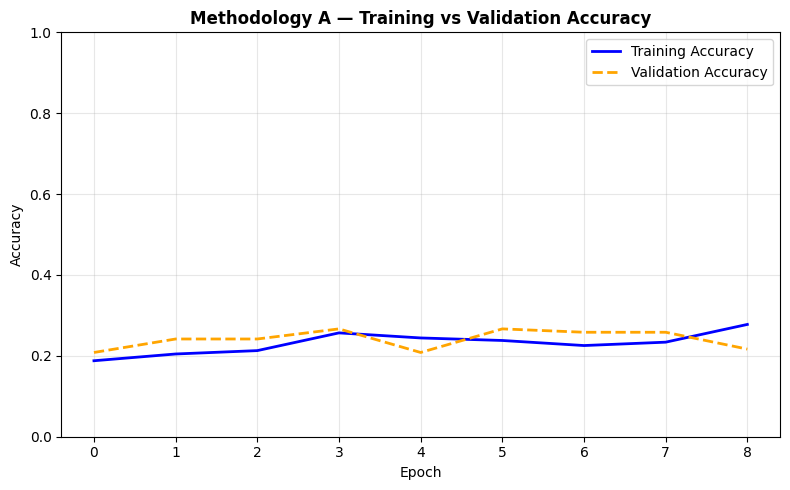

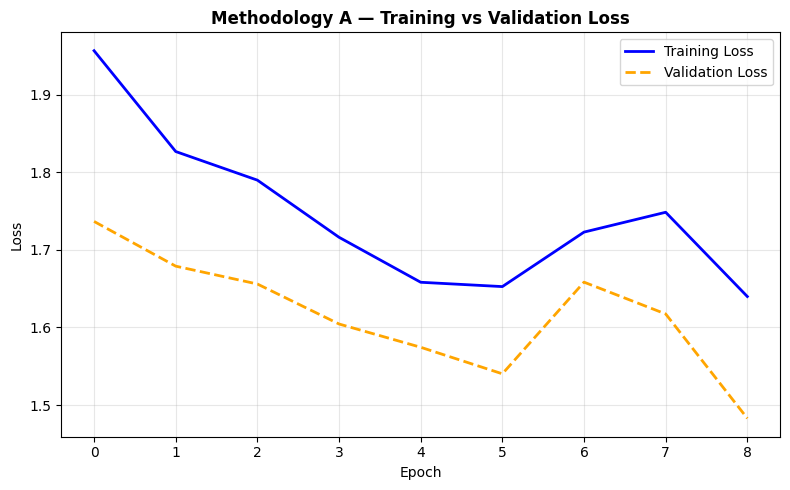

In [40]:

import matplotlib.pyplot as plt

# ── Methodology A: Accuracy Graph ─────────────────────────────────────
plt.figure(figsize=(8, 5))
plt.plot(history_baseline.history['accuracy'],
         label='Training Accuracy', linewidth=2, color='blue')
plt.plot(history_baseline.history['val_accuracy'],
         label='Validation Accuracy', linewidth=2, linestyle='--', color='orange')
plt.title('Methodology A — Training vs Validation Accuracy', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('methodology_a_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Methodology A: Loss Graph ──────────────────────────────────────────
plt.figure(figsize=(8, 5))
plt.plot(history_baseline.history['loss'],
         label='Training Loss', linewidth=2, color='blue')
plt.plot(history_baseline.history['val_loss'],
         label='Validation Loss', linewidth=2, linestyle='--', color='orange')
plt.title('Methodology A — Training vs Validation Loss', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('methodology_a_loss.png', dpi=150, bbox_inches='tight')
plt.show()


Improved Model:MobilenetV2+LSTM(Transfer learning)

In [18]:
# ── Transfer Learning Model: MobileNetV2 + LSTM ───────────────────────

# Load MobileNetV2 pre-trained on ImageNet, excluding the classification head
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze all backbone layers to prevent their weights from being updated during training
base_model.trainable = False

print(f"MobileNetV2 loaded. Trainable: {base_model.trainable}")
print(f"Total backbone parameters  : {base_model.count_params():,}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
MobileNetV2 loaded. Trainable: False
Total backbone parameters  : 2,257,984


In [19]:
# Build the complete MobileNetV2 + LSTM model
model = Sequential([
    Input(shape=(SEQUENCE_LENGTH, IMG_SIZE, IMG_SIZE, 3)),

    # Apply frozen MobileNetV2 to each frame independently
    TimeDistributed(base_model),

    # Pool spatial dimensions → one feature vector per frame
    TimeDistributed(GlobalAveragePooling2D()),

    # Temporal modelling across the frame sequence
    LSTM(128, return_sequences=False),
    Dropout(0.5),

    # Classification head
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax')
], name='MobileNetV2_LSTM')

model.summary()

Model: "MobileNetV2_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_10             │ (None, 20, 3, 3, 1280) │     2,257,984 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_11             │ (None, 20, 1280)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       721,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,988,038 (11.40 MB)

 Trainable params: 730,054 (2.78 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [30]:
# Compile with a lower learning rate appropriate for fine-tuning
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Training callbacks
callbacks_improved = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='best_model_mobilenet.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# Train the improved model
# Note: batch_size=4 is used due to the large memory footprint of MobileNetV2 per frame
history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=4,
    validation_data=(X_test, y_test),
    callbacks=callbacks_improved,
    verbose=1
)

Epoch 1/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 636ms/step - accuracy: 0.8306 - loss: 0.4149
Epoch 1: val_accuracy improved from None to 0.75833, saving model to best_model_mobilenet.keras

Epoch 1: finished saving model to best_model_mobilenet.keras
120/120 ━━━━━━━━━━━━━━━━━━━━ 237s 1s/step - accuracy: 0.8643 - loss: 0.3639 - val_accuracy: 0.7583 - val_loss: 0.5211 - learning_rate: 1.0000e-04
Epoch 2/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 654ms/step - accuracy: 0.8338 - loss: 0.4193
Epoch 2: val_accuracy did not improve from 0.75833
120/120 ━━━━━━━━━━━━━━━━━━━━ 99s 824ms/step - accuracy: 0.8539 - loss: 0.3840 - val_accuracy: 0.7500 - val_loss: 0.5440 - learning_rate: 1.0000e-04
Epoch 3/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 633ms/step - accuracy: 0.8858 - loss: 0.3170
Epoch 3: val_accuracy improved from 0.75833 to 0.76667, saving model to best_model_mobilenet.keras

Epoch 3: finished saving model to best_model_mobilenet.keras
120/120 ━━━━━━━━━━━━━━━━━━━━ 97s 812ms/step - accuracy: 0.8831 - loss: 0

Model Evaluation and Metrics

In [31]:
# Evaluate the improved model on the test set
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print('MobileNetV2 + LSTM — Test Set Evaluation')
print(f'  Test Loss     : {loss:.4f}')
print(f'  Test Accuracy : {accuracy:.4f} ({accuracy * 100:.2f}%)')

MobileNetV2 + LSTM — Test Set Evaluation
  Test Loss     : 0.5041
  Test Accuracy : 0.8083 (80.83%)


In [32]:
# Generate predictions on the test set
y_pred_prob    = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred_prob, axis=1)  # Predicted class indices
y_true         = np.argmax(y_test, axis=1)       # Ground truth class indices

# Per-class classification report
print('Classification Report (MobileNetV2 + LSTM):')
print('=' * 60)
print(classification_report(y_true, y_pred_classes, target_names=CLASSES))

Classification Report (MobileNetV2 + LSTM):
              precision    recall  f1-score   support

      boxing       0.95      1.00      0.98        20
handclapping       0.89      0.85      0.87        20
  handwaving       0.90      0.90      0.90        20
     jogging       0.55      0.55      0.55        20
     running       0.78      0.70      0.74        20
     walking       0.77      0.85      0.81        20

    accuracy                           0.81       120
   macro avg       0.81      0.81      0.81       120
weighted avg       0.81      0.81      0.81       120



In [33]:
# Model comparison summary
print('Model Performance Comparison')
print('=' * 50)
print(f'  Baseline (CNN + LSTM)      : 26.67%')
print(f'  Improved (MobileNetV2+LSTM): 80.83%')
print(f'  Accuracy improvement       : +51.00 percentage points')

Model Performance Comparison
  Baseline (CNN + LSTM)      : 26.67%
  Improved (MobileNetV2+LSTM): 80.83%
  Accuracy improvement       : +51.00 percentage points


Visulation: Confusion Matrix and Training Curves

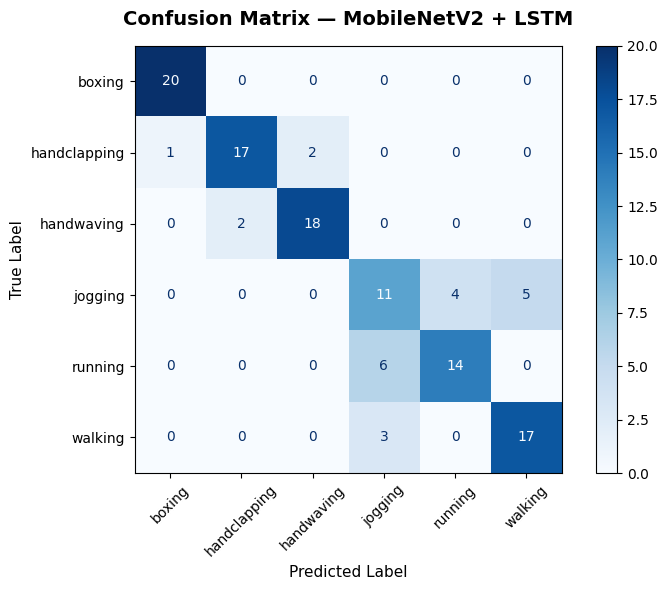

Confusion matrix saved as confusion_matrix.png


In [34]:
# ── Confusion Matrix ───────────────────────────────────────────────────
cm   = confusion_matrix(y_true, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', xticks_rotation=45, ax=ax, colorbar=True)
ax.set_title('Confusion Matrix — MobileNetV2 + LSTM', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved as confusion_matrix.png")

Training and Validation Curves

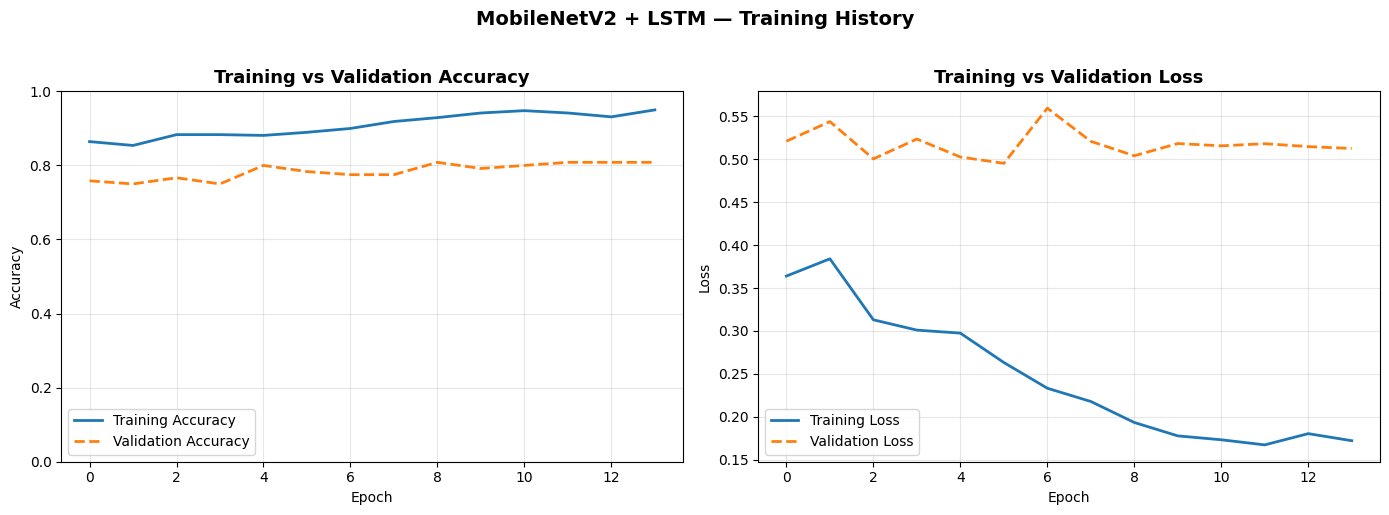

Training curves saved as training_curves.png


In [35]:
# ── Training Curves: Accuracy and Loss ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Accuracy Curve ---
axes[0].plot(history.history['accuracy'],     label='Training Accuracy',   linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, linestyle='--')
axes[0].set_title('Training vs Validation Accuracy', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 1])

# --- Loss Curve ---
axes[1].plot(history.history['loss'],     label='Training Loss',   linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2, linestyle='--')
axes[1].set_title('Training vs Validation Loss', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('MobileNetV2 + LSTM — Training History', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Training curves saved as training_curves.png")

Model Export

In [36]:
# Persist the final trained model to the Colab runtime filesystem
model.save('final_kth_action_model.keras')
print("Model saved successfully as final_kth_action_model.keras")

# List all output files
output_files = ['best_model_mobilenet.keras', 'final_kth_action_model.keras',
                'confusion_matrix.png', 'training_curves.png']
print('\nOutput files:')
for f in output_files:
    if os.path.exists(f):
        size_mb = os.path.getsize(f) / (1024 * 1024)
        print(f'  {f:<45} ({size_mb:.2f} MB)')

Model saved successfully as final_kth_action_model.keras

Output files:
  best_model_mobilenet.keras                    (17.55 MB)
  final_kth_action_model.keras                  (17.55 MB)
  confusion_matrix.png                          (0.07 MB)
  training_curves.png                           (0.10 MB)


In [37]:
# Download the final model file to your local machine
from google.colab import files
files.download('final_kth_action_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>